In [ ]:
# import requests
import pandas as pd
import numpy as np
from scipy.stats import entropy
import scipy.stats as stats

# import matplotlib.pyplot as plt
# import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          
from sklearn.model_selection import TimeSeriesSplit


import itertools
import pickle

import time
# import yaml
pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

## 1. Data Preparation

In [2]:
df = pd.read_csv("italy_unemployment_rate_PREDICTION_DATASET.csv")

In [3]:
df

,date,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate_diff
0,2014-02-01,2,1.12,0.00,87.30,0.50,0.07,1.01,0.01,0.06,0.13,-0.02
1,2014-03-01,3,0.17,-0.20,89.20,0.15,0.04,1.32,0.01,0.04,0.10,-0.73
2,2014-04-01,4,-1.24,-0.20,88.30,-0.00,0.03,-2.75,0.00,0.03,0.08,-0.30
3,2014-05-01,5,2.21,-0.10,87.60,-0.07,0.04,1.92,0.01,0.05,0.07,-0.12
4,2014-06-01,6,-0.40,0.20,89.30,-0.16,-0.03,-1.47,-0.01,0.04,0.07,-1.50
...,...,...,...,...,...,...,...,...,...,...,...,...
151,2026-09-01,9,0.04,0.13,96.27,0.02,-0.17,0.42,0.00,0.02,-0.01,NaN
152,2026-10-01,10,0.04,0.49,96.15,-0.02,-0.09,0.19,0.00,-0.01,0.01,NaN
153,2026-11-01,11,0.04,0.04,95.81,-0.02,-0.11,-0.36,0.00,0.00,0.00,NaN
154,2026-12-01,12,0.04,0.95,95.33,-0.07,-0.09,0.11,-0.00,-0.00,0.00,NaN


In [4]:
# df['date'] = pd.to_datetime(df['Unnamed: 0'])
# X_columns = df.set_index('date')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [5]:
df.index.name = None

In [6]:
df_target = df[['unemployment_rate_diff']]
df.drop('unemployment_rate_diff', axis = 1, inplace = True)

In [7]:
df_target.dropna(axis= 0, inplace =True)
df_target

,unemployment_rate_diff
2014-02-01,-0.02
2014-03-01,-0.73
2014-04-01,-0.30
2014-05-01,-0.12
2014-06-01,-1.50
...,...
2025-09-01,0.72
2025-10-01,-0.40
2025-11-01,-0.12
2025-12-01,0.31


In [8]:
selected_cols = ['month', 
                          'employment_rate_diff', 
                         'industry_production_prices_diff',
                         'companies_trust', 
                        # 'rolling_mean_3m', 
                        'rolling_mean_6m',
                        'rolling_mean_12m', 
                        # 'rolling_std_12m', 
                        'PCA_labour_market_1',
                        'PCA_labour_market_2', 
                        'PCA_price_energy_1', 
                         'PCA_price_energy_2'
                        ]  

In [9]:
X_train = df.iloc[:-12]
X_test = df.iloc[-12:]

y_train = df_target['unemployment_rate_diff']
# y_test = df_target.iloc[-12:][['unemployment_rate_diff']]

In [10]:
X_train

,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2
2014-02-01,2,1.12,0.00,87.30,0.50,0.07,1.01,0.01,0.06,0.13
2014-03-01,3,0.17,-0.20,89.20,0.15,0.04,1.32,0.01,0.04,0.10
2014-04-01,4,-1.24,-0.20,88.30,-0.00,0.03,-2.75,0.00,0.03,0.08
2014-05-01,5,2.21,-0.10,87.60,-0.07,0.04,1.92,0.01,0.05,0.07
2014-06-01,6,-0.40,0.20,89.30,-0.16,-0.03,-1.47,-0.01,0.04,0.07
...,...,...,...,...,...,...,...,...,...,...
2025-09-01,9,0.78,0.30,93.80,-0.13,0.03,1.41,0.00,0.02,0.01
2025-10-01,10,-0.83,-0.30,94.40,-0.10,-0.02,-0.17,0.02,-0.01,0.02
2025-11-01,11,-0.28,1.20,96.10,-0.26,-0.03,-1.94,0.03,0.07,-0.02
2025-12-01,12,0.43,-0.90,96.50,-0.16,-0.08,0.66,0.02,-0.05,0.04


In [11]:
X_train.index

DatetimeIndex(['2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01',
               '2014-06-01', '2014-07-01', '2014-08-01', '2014-09-01',
               '2014-10-01', '2014-11-01',
               ...
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01'],
              dtype='datetime64[us]', length=144, freq=None)

## 2. Model: SARIMAX

Riparti da qui§

In [12]:
# best_param_V1 = (1, 1, 0)
# best_param_seasonal_V1 = (0, 1, 0, 12)


best_param = (0, 0, 0)
best_param_seasonal = (1, 0, 0, 12)

# best_param_V2 = (0, 2, 2)
# best_param_seasonal_V2 = (0, 2, 2, 12)

### 2.1 training

In [13]:
print(y_train.index[:5])
print(X_train.index[:5])

print(len(y_train))
print(len(X_train))

DatetimeIndex(['2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01',
               '2014-06-01'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2014-02-01', '2014-03-01', '2014-04-01', '2014-05-01',
               '2014-06-01'],
              dtype='datetime64[us]', freq=None)
144
144


In [14]:
model = SARIMAX(y_train,
                exog=X_train, #[selected_cols], 
                order=best_param,
                seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()

In [15]:
model = SARIMAX(y_train,
                exog=X_train[selected_cols], 
                order=best_param,
                seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


#################################################################
######################## FORECASTING  ###############################
#################################################################


y_test_pred = results.predict(
        start=X_test.index[0],
        end=X_test.index[-1],
        exog=X_test[selected_cols]
            )

In [16]:
y_test_pred = results.get_forecast(
    steps=len(X_test),
    exog=X_test
)

y_test_pred_mean = y_test_pred.predicted_mean
conf_int = y_test_pred.conf_int(alpha=0.05)  # IC 95%

### 2.2 testing

In [17]:
df_target_1 = pd.concat([df_target, y_test_pred_mean], axis = 1)

df_target_1['unemployment_rate_diff'] = df_target_1.unemployment_rate_diff.fillna(y_test_pred_mean)

df_target_2 = pd.concat([df_target_1, conf_int ], axis = 1)


In [18]:
df_target_2

,unemployment_rate_diff,predicted_mean,lower unemployment_rate_diff,upper unemployment_rate_diff
2014-02-01,-0.02,NaN,NaN,NaN
2014-03-01,-0.73,NaN,NaN,NaN
2014-04-01,-0.30,NaN,NaN,NaN
2014-05-01,-0.12,NaN,NaN,NaN
2014-06-01,-1.50,NaN,NaN,NaN
...,...,...,...,...
2026-09-01,0.27,0.27,-0.55,1.08
2026-10-01,0.00,0.00,-0.81,0.82
2026-11-01,0.07,0.07,-0.75,0.88
2026-12-01,0.20,0.20,-0.61,1.02


In [19]:
df_final = pd.concat([df, df_target_2], axis = 1)

In [20]:
df_final

,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate_diff,predicted_mean,lower unemployment_rate_diff,upper unemployment_rate_diff
2014-02-01,2,1.12,0.00,87.30,0.50,0.07,1.01,0.01,0.06,0.13,-0.02,NaN,NaN,NaN
2014-03-01,3,0.17,-0.20,89.20,0.15,0.04,1.32,0.01,0.04,0.10,-0.73,NaN,NaN,NaN
2014-04-01,4,-1.24,-0.20,88.30,-0.00,0.03,-2.75,0.00,0.03,0.08,-0.30,NaN,NaN,NaN
2014-05-01,5,2.21,-0.10,87.60,-0.07,0.04,1.92,0.01,0.05,0.07,-0.12,NaN,NaN,NaN
2014-06-01,6,-0.40,0.20,89.30,-0.16,-0.03,-1.47,-0.01,0.04,0.07,-1.50,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,9,0.04,0.13,96.27,0.02,-0.17,0.42,0.00,0.02,-0.01,0.27,0.27,-0.55,1.08
2026-10-01,10,0.04,0.49,96.15,-0.02,-0.09,0.19,0.00,-0.01,0.01,0.00,0.00,-0.81,0.82
2026-11-01,11,0.04,0.04,95.81,-0.02,-0.11,-0.36,0.00,0.00,0.00,0.07,0.07,-0.75,0.88
2026-12-01,12,0.04,0.95,95.33,-0.07,-0.09,0.11,-0.00,-0.00,0.00,0.20,0.20,-0.61,1.02


In [21]:
# df.to_excel('Italy_revenues_predicted_2026.xlsx', index=False)

In [31]:
import pickle

In [22]:
df_final

,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate_diff,predicted_mean,lower unemployment_rate_diff,upper unemployment_rate_diff
2014-02-01,2,1.12,0.00,87.30,0.50,0.07,1.01,0.01,0.06,0.13,-0.02,NaN,NaN,NaN
2014-03-01,3,0.17,-0.20,89.20,0.15,0.04,1.32,0.01,0.04,0.10,-0.73,NaN,NaN,NaN
2014-04-01,4,-1.24,-0.20,88.30,-0.00,0.03,-2.75,0.00,0.03,0.08,-0.30,NaN,NaN,NaN
2014-05-01,5,2.21,-0.10,87.60,-0.07,0.04,1.92,0.01,0.05,0.07,-0.12,NaN,NaN,NaN
2014-06-01,6,-0.40,0.20,89.30,-0.16,-0.03,-1.47,-0.01,0.04,0.07,-1.50,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,9,0.04,0.13,96.27,0.02,-0.17,0.42,0.00,0.02,-0.01,0.27,0.27,-0.55,1.08
2026-10-01,10,0.04,0.49,96.15,-0.02,-0.09,0.19,0.00,-0.01,0.01,0.00,0.00,-0.81,0.82
2026-11-01,11,0.04,0.04,95.81,-0.02,-0.11,-0.36,0.00,0.00,0.00,0.07,0.07,-0.75,0.88
2026-12-01,12,0.04,0.95,95.33,-0.07,-0.09,0.11,-0.00,-0.00,0.00,0.20,0.20,-0.61,1.02


In [23]:
col = 'unemployment_rate_diff'

df_final.loc[df_final.index[0], col] = 14.13

df_final[f'unemployment_rate_reconstructed'] = (df_final['unemployment_rate_diff'].cumsum())

In [25]:
df_final.tail(4)


,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_6m,rolling_mean_12m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate_diff,predicted_mean,lower unemployment_rate_diff,upper unemployment_rate_diff,unemployment_rate_reconstructed
2026-10-01,10,0.04,0.49,96.15,-0.02,-0.09,0.19,0.00,-0.01,0.01,0.00,0.00,-0.81,0.82,4.61
2026-11-01,11,0.04,0.04,95.81,-0.02,-0.11,-0.36,0.00,0.00,0.00,0.07,0.07,-0.75,0.88,4.67
2026-12-01,12,0.04,0.95,95.33,-0.07,-0.09,0.11,-0.00,-0.00,0.00,0.20,0.20,-0.61,1.02,4.88
2027-01-01,1,0.04,-0.16,94.92,-0.08,-0.03,-0.13,0.00,0.00,-0.00,-0.40,-0.40,-1.22,0.41,4.47


In [26]:
# primo indice della forecast
first_forecast_idx = df_final['upper unemployment_rate_diff'].first_valid_index()

# valore iniziale della target ricostruita
base_value = df_final.loc[first_forecast_idx, 'unemployment_rate_reconstructed']

# ricostruzione lower e upper
mask = df_final['upper unemployment_rate_diff'].notna()


df_final.loc[mask, 'lower_reconstructed'] = (
    df_final.loc[mask, 'lower unemployment_rate_diff'].cumsum()
    + base_value
)


df_final.loc[mask, 'upper_reconstructed'] = (
    df_final.loc[mask, 'upper unemployment_rate_diff'].cumsum()
    + base_value
)


In [30]:
df_final[['month', 'unemployment_rate_reconstructed']].tail(16)

,month,unemployment_rate_reconstructed
2025-10-01,10,5.64
2025-11-01,11,5.52
2025-12-01,12,5.83
2026-01-01,1,5.21
2026-02-01,2,5.02
2026-03-01,3,4.69
2026-04-01,4,4.46
2026-05-01,5,4.70
2026-06-01,6,4.71
2026-07-01,7,4.45


# Results analysis

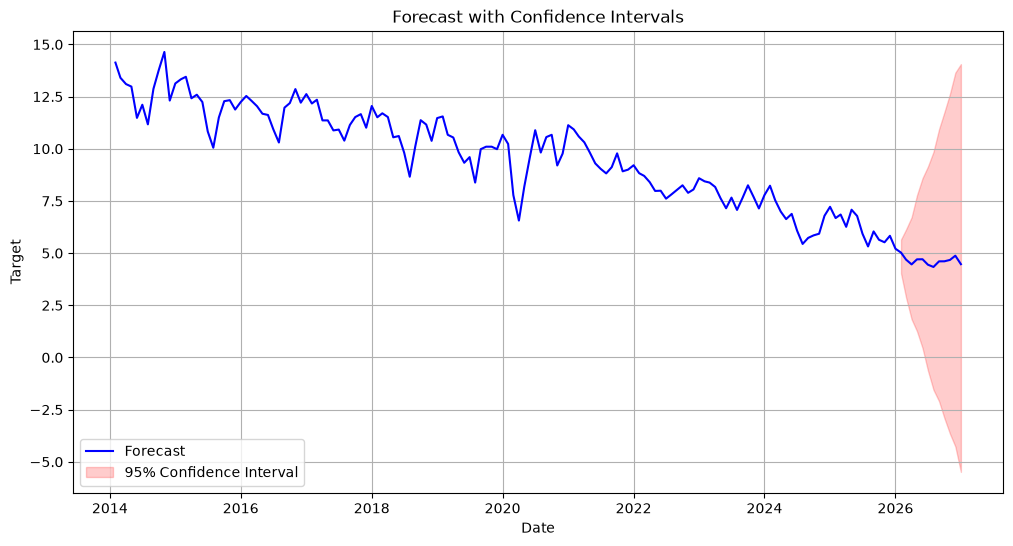

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Valori predetti
plt.plot(
    df_final['unemployment_rate_reconstructed'].index,
    df_final['unemployment_rate_reconstructed'],
    color='blue',
    label='Forecast'
)

# Bande di confidenza
plt.fill_between(
    df_final['unemployment_rate_reconstructed'].index,
    df_final['lower_reconstructed'],
    df_final['upper_reconstructed'],
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title('Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)

plt.show()